In [ ]:
# ==========================================
# MONTAR DRIVE Y DESCOMPRIMIR DATASET
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Ruta al archivo ZIP en Drive
ruta_zip = "/content/drive/MyDrive/Colab Notebooks/archive.zip"

# Descomprimir en el directorio actual
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall('.')

# Verificar que el archivo CSV está disponible
print("📁 Archivos en el directorio actual:")
print(os.listdir('.'))

# Verificar que netflix_titles.csv está presente
if 'netflix_titles.csv' in os.listdir('.'):
    print("✅ netflix_titles.csv encontrado")
else:
    print("❌ netflix_titles.csv NO encontrado. Verificá la ruta del ZIP.")

Mounted at /content/drive
📁 Archivos en el directorio actual:
['.config', 'netflix_titles.csv', 'drive', 'sample_data']
✅ netflix_titles.csv encontrado


In [ ]:
# ==========================================
# SETUP COMPLETO + DESCOMPRESIÓN + KPIs
# (Ejecutar siempre primero)
# ==========================================

# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Montar Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Descomprimir el dataset
import zipfile
import os

# Ruta al ZIP en Drive
ruta_zip = "/content/drive/MyDrive/Colab Notebooks/archive.zip"

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall('.')

print("✅ Archivo descomprimido")

# 4. Cargar el dataset
df = pd.read_csv("netflix_titles.csv")
print("✅ Dataset cargado correctamente")
print("📊 Tamaño:", df.shape)

print("\n" + "="*50)
print("📊 KPIs DEL PROYECTO")
print("="*50)

# 5. Calcular KPIs
porcentaje_tipo = df['type'].value_counts(normalize=True) * 100
print("\n📊 KPI 1 - Proporción de contenido:")
print(porcentaje_tipo)

generos = df['listed_in'].str.split(', ').explode()
top_generos = generos.value_counts().head(3)
print("\n🎬 KPI 2 - Top 3 géneros más comunes:")
print(top_generos)

anio_pico = df['release_year'].mode()[0]
cantidad_anio_pico = df[df['release_year'] == anio_pico].shape[0]
print("\n📅 KPI 3 - Año con más estrenos:")
print(f"Año: {anio_pico} - Cantidad de títulos: {cantidad_anio_pico}")

print("\n" + "="*50)
print("✅ SETUP COMPLETADO. ¡Podés empezar a trabajar!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Archivo descomprimido
✅ Dataset cargado correctamente
📊 Tamaño: (8807, 12)

📊 KPIs DEL PROYECTO

📊 KPI 1 - Proporción de contenido:
type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

🎬 KPI 2 - Top 3 géneros más comunes:
listed_in
International Movies    2752
Dramas                  2427
Comedies                1674
Name: count, dtype: int64

📅 KPI 3 - Año con más estrenos:
Año: 2018 - Cantidad de títulos: 1147

✅ SETUP COMPLETADO. ¡Podés empezar a trabajar!


In [ ]:
import zipfile
import os

# Ruta al archivo ZIP en Drive (verificá que esté en "Colab Notebooks")
ruta_zip = "/content/drive/MyDrive/Colab Notebooks/archive.zip"

# Descomprimir el archivo en el directorio actual de Colab
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall('.')

# Ver qué archivos se extrajeron
print("📁 Archivos extraídos:")
print(os.listdir('.'))

📁 Archivos extraídos:
['.config', 'netflix_titles.csv', 'drive', 'sample_data']


In [ ]:
# Montar Google Drive para acceder a los archivos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Cargar el archivo CSV descomprimido
df = pd.read_csv("netflix_titles.csv")

# Verificar que se cargó correctamente
print("✅ Dataset cargado correctamente")
print("📊 Tamaño del dataset (filas, columnas):", df.shape)

✅ Dataset cargado correctamente
📊 Tamaño del dataset (filas, columnas): (8807, 12)


In [ ]:
# ==========================================
# LIMPIEZA DE NULOS (Primera iteración)
# ==========================================

# 1. Rellenar 'director' y 'cast' con "Desconocido"
df['director'] = df['director'].fillna("Desconocido")
df['cast'] = df['cast'].fillna("Desconocido")

# 2. Rellenar 'country' con el país más frecuente (moda)
moda_pais = df['country'].mode()[0]
df['country'] = df['country'].fillna(moda_pais)

# 3. Rellenar 'rating' con "Sin Clasificar" (porque es una categoría)
df['rating'] = df['rating'].fillna("Sin Clasificar")

# 4. Eliminar filas donde 'date_added' sea nulo (porque son pocas y es una fecha clave)
df = df.dropna(subset=['date_added'])

# 5. Verificar que ya no hay nulos
print("🔍 Nulos después de la limpieza:")
print(df.isnull().sum())

🔍 Nulos después de la limpieza:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


In [ ]:
# Eliminar las filas donde 'duration' sea nulo (son solo 3)
df = df.dropna(subset=['duration'])

# Verificar que ya no hay nulos en todo el dataset
print("✅ Nulos finales (debe dar todo 0):")
print(df.isnull().sum())

✅ Nulos finales (debe dar todo 0):
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


## Resumen final de limpieza de datos

**Columnas con nulos y tratamiento aplicado:**

- **director** y **cast**: se rellenaron con "Desconocido" (valores categóricos).
- **country**: se imputó con la moda ("United States").
- **rating**: se imputó con "Sin Clasificar".
- **date_added**: se eliminaron las filas con nulos (<2% del total).
- **duration**: se eliminaron las 3 filas con nulos (<0.1% del total).

**Verificación:** Después de la limpieza, no quedan valores nulos en el dataset.

In [ ]:
# ==========================================
# EXPLORACIÓN AVANZADA DEL DATASET NETFLIX
# ==========================================

print("="*50)
print("1. TOP 5 PAÍSES CON MÁS CONTENIDO:")
print(df['country'].value_counts().head(5))

print("\n"+"="*50)
print("2. TOP 5 GÉNEROS MÁS FRECUENTES:")
# Separar los géneros (vienen como "Comedias, Dramas, Internacional")
todos_los_generos = df['listed_in'].str.split(', ').explode()
print(todos_los_generos.value_counts().head(5))

print("\n"+"="*50)
print("3. DÉCADA CON MÁS ESTRENOS:")
# Crear columna de década y mostrar las más recientes
df['decada'] = (df['release_year'] // 10) * 10
print(df['decada'].value_counts().sort_index().tail(5))

print("\n"+"="*50)
print("4. DURACIÓN PROMEDIO DE PELÍCULAS (minutos):")
# Filtrar solo películas y extraer duración en minutos
peliculas = df[df['type'] == 'Movie']
duracion_min = peliculas['duration'].str.extract('(\d+)').astype(float)
print("Promedio:", duracion_min.mean()[0])
print("Mínimo:", duracion_min.min()[0])
print("Máximo:", duracion_min.max()[0])

print("\n"+"="*50)
print("5. AÑOS CON MÁS ESTRENOS EN NETFLIX (Top 5):")
print(df['release_year'].value_counts().head(5))

1. TOP 5 PAÍSES CON MÁS CONTENIDO:
country
United States     3639
India              972
United Kingdom     418
Japan              244
South Korea        199
Name: count, dtype: int64

2. TOP 5 GÉNEROS MÁS FRECUENTES:
listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1350
Documentaries              869
Name: count, dtype: int64

3. DÉCADA CON MÁS ESTRENOS:
decada
1980     129
1990     274
2000     807
2010    5917
2020    1545
Name: count, dtype: int64

4. DURACIÓN PROMEDIO DE PELÍCULAS (minutos):
Promedio: 99.57718668407311
Mínimo: 3.0
Máximo: 312.0

5. AÑOS CON MÁS ESTRENOS EN NETFLIX (Top 5):
release_year
2018    1146
2017    1031
2019    1030
2020     953
2016     901
Name: count, dtype: int64


<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2537/2128041703.py:25: SyntaxWarning: invalid escape sequence '\d'
  duracion_min = peliculas['duration'].str.extract('(\d+)').astype(float)


In [ ]:
# ==========================================
# MONTAR DRIVE Y DESCOMPRIMIR DATASET
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Ruta al archivo ZIP en Drive
ruta_zip = "/content/drive/MyDrive/Colab Notebooks/archive.zip"

# Descomprimir en el directorio actual
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall('.')

# Verificar que el archivo CSV está disponible
print("📁 Archivos en el directorio actual:")
print(os.listdir('.'))

# Verificar que netflix_titles.csv está presente
if 'netflix_titles.csv' in os.listdir('.'):
    print("✅ netflix_titles.csv encontrado")
else:
    print("❌ netflix_titles.csv NO encontrado. Verificá la ruta del ZIP.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Archivos en el directorio actual:
['.config', 'netflix_titles.csv', 'drive', 'sample_data']
✅ netflix_titles.csv encontrado


In [ ]:
# ==========================================
# SETUP DEL NOTEBOOK
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv("netflix_titles.csv")

# Verificar que se cargó
print("✅ Setup completado correctamente")
print("📊 Dataset cargado. Tamaño:", df.shape)
print("🔍 Primeras 3 filas:")
print(df.head(3))

✅ Setup completado correctamente
📊 Dataset cargado. Tamaño: (8807, 12)
🔍 Primeras 3 filas:
  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water              NaN   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021          2021  TV-MA   1 Season   

                                           listed_in  \
0                                      Documentaries   
1    International TV Shows, TV Dramas

/tmp/ipykernel_2537/1447454433.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


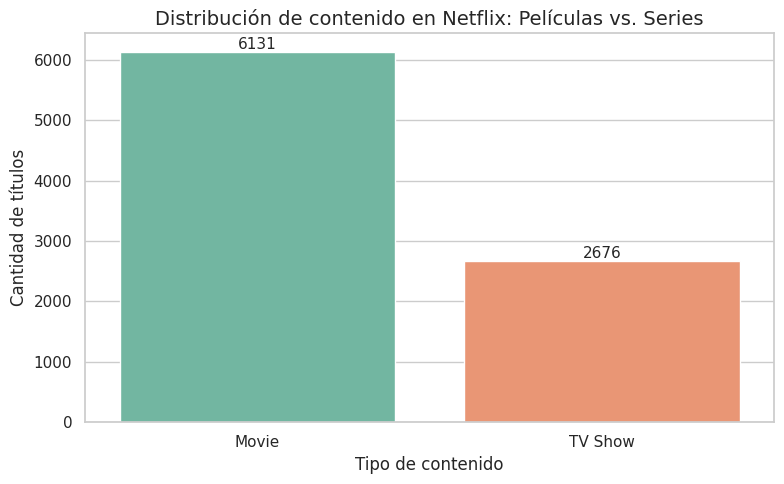

In [ ]:
# ==========================================
# GRÁFICO 1: Películas vs. Series
# ==========================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type', palette='Set2')

plt.title('Distribución de contenido en Netflix: Películas vs. Series', fontsize=14)
plt.xlabel('Tipo de contenido', fontsize=12)
plt.ylabel('Cantidad de títulos', fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2537/2336455764.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette='viridis')


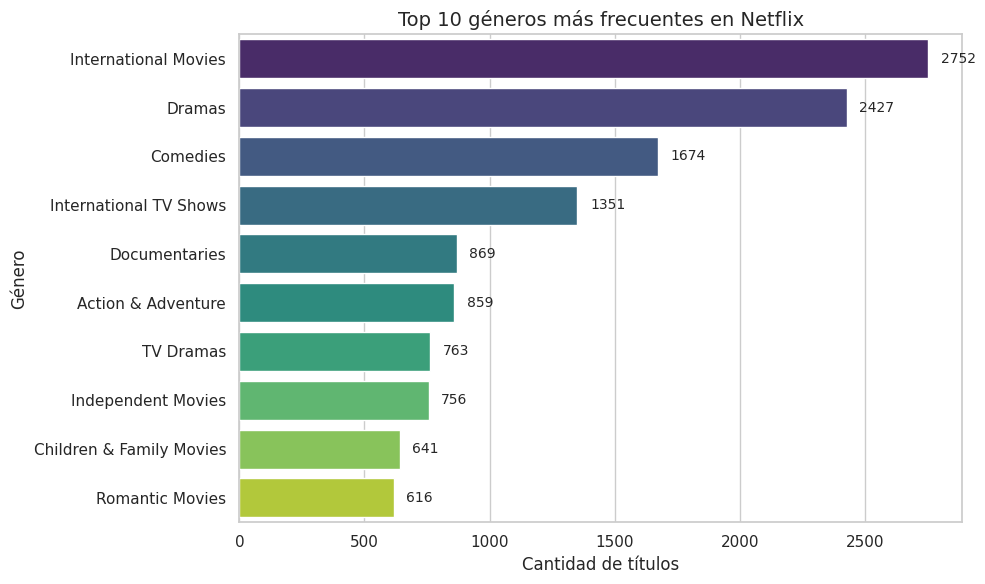

In [ ]:
# ==========================================
# GRÁFICO 2: Top 10 géneros más comunes
# ==========================================

# Separar los géneros (vienen como "Comedias, Dramas, Internacional")
generos = df['listed_in'].str.split(', ').explode()

# Contar los 10 géneros más frecuentes
top_generos = generos.value_counts().head(10)

# Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.barplot(x=top_generos.values, y=top_generos.index, palette='viridis')

# Personalizar
plt.title('Top 10 géneros más frecuentes en Netflix', fontsize=14)
plt.xlabel('Cantidad de títulos', fontsize=12)
plt.ylabel('Género', fontsize=12)

# Mostrar valores al final de cada barra
for i, v in enumerate(top_generos.values):
    plt.text(v + 50, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

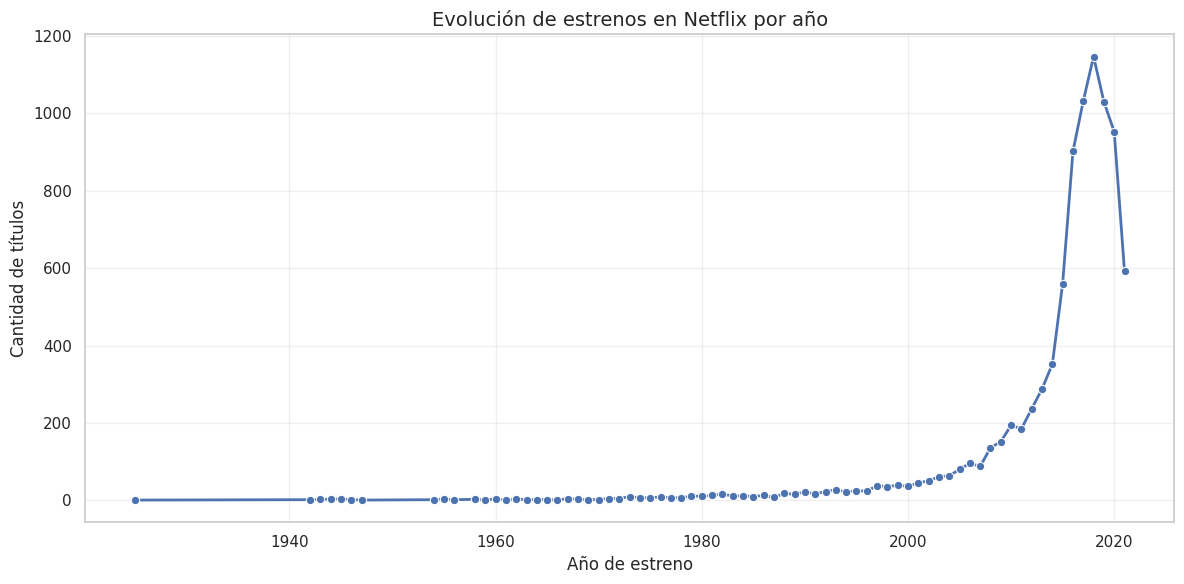

In [ ]:
# ==========================================
# GRÁFICO 3: Estrenos por año
# ==========================================

# Contar títulos por año de estreno
estrenos_por_año = df['release_year'].value_counts().sort_index()

# Crear el gráfico de líneas
plt.figure(figsize=(12, 6))
sns.lineplot(x=estrenos_por_año.index, y=estrenos_por_año.values, marker='o', linewidth=2)

# Personalizar
plt.title('Evolución de estrenos en Netflix por año', fontsize=14)
plt.xlabel('Año de estreno', fontsize=12)
plt.ylabel('Cantidad de títulos', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación del Gráfico 3

El gráfico de líneas muestra la evolución de los estrenos en Netflix a lo largo del tiempo. Se observa un **crecimiento exponencial a partir de la década de 2010**, con un pico notable alrededor del año 2020. Este comportamiento refleja la estrategia de expansión de Netflix, que comenzó a producir y agregar contenido masivamente a partir de ese período, consolidándose como la plataforma de streaming líder a nivel mundial. La tendencia ascendente también evidencia el aumento en la demanda de contenido digital durante los últimos años.

/tmp/ipykernel_2537/3572852774.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.values, y=top_paises.index, palette='coolwarm')


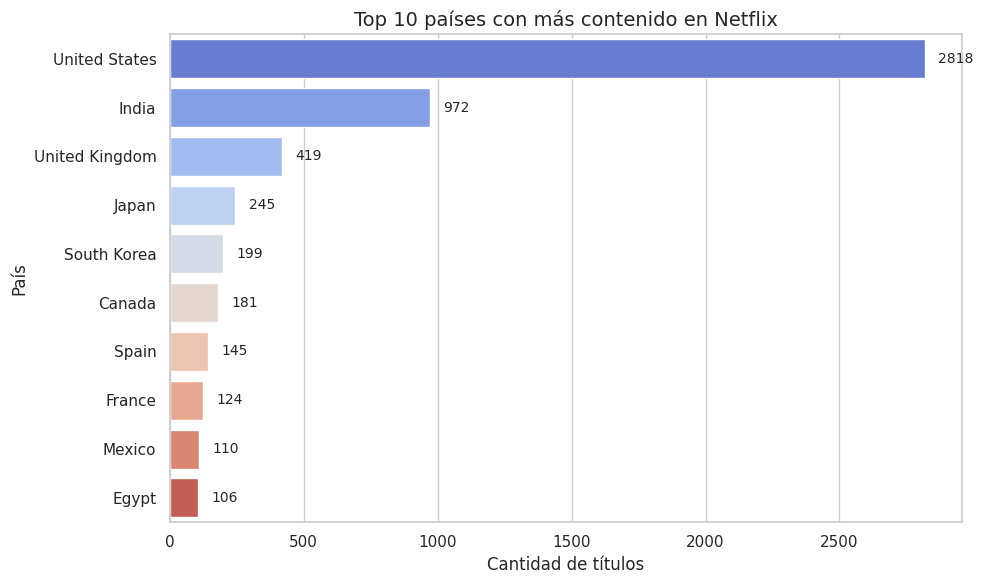

In [ ]:
# ==========================================
# GRÁFICO 4: Top 10 países con más contenido
# ==========================================

# Top 10 países
top_paises = df['country'].value_counts().head(10)

# Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.barplot(x=top_paises.values, y=top_paises.index, palette='coolwarm')

# Personalizar
plt.title('Top 10 países con más contenido en Netflix', fontsize=14)
plt.xlabel('Cantidad de títulos', fontsize=12)
plt.ylabel('País', fontsize=12)

# Mostrar valores al final de cada barra
for i, v in enumerate(top_paises.values):
    plt.text(v + 50, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretación del Gráfico 4

El gráfico de barras horizontales muestra que **Estados Unidos** es, con gran diferencia, el país que más contenido aporta al catálogo de Netflix. Le siguen países como India, Reino Unido y Canadá, aunque con cifras mucho menores. Esta distribución refleja la fuerte presencia de la industria audiovisual estadounidense en la plataforma y su influencia en la oferta de contenido global.

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2537/3190840056.py:7: SyntaxWarning: invalid escape sequence '\d'
  duracion = peliculas['duration'].str.extract('(\d+)').astype(float)


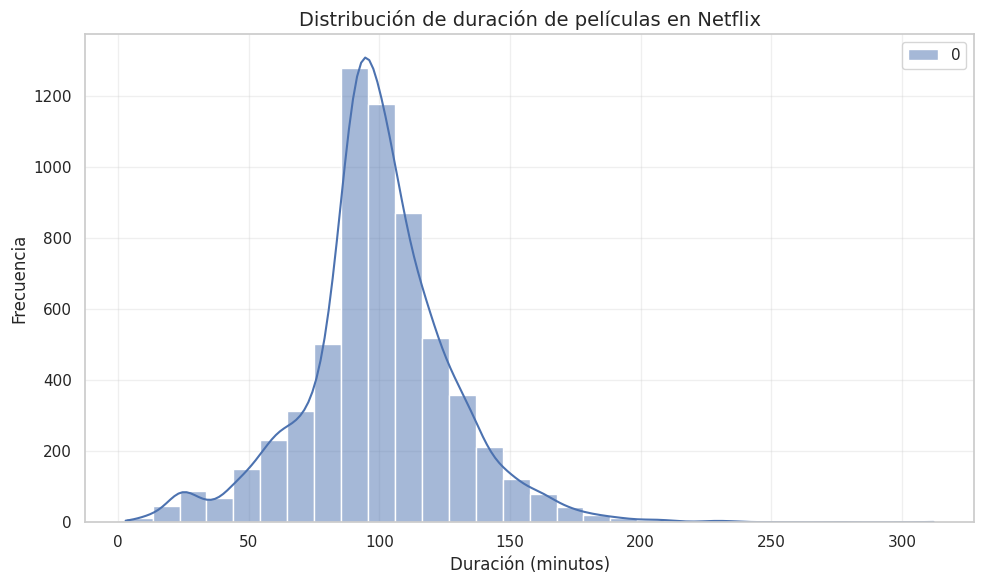

In [ ]:
# ==========================================
# GRÁFICO 5: Distribución de duración de películas
# ==========================================

# Filtrar solo películas y extraer duración en minutos
peliculas = df[df['type'] == 'Movie']
duracion = peliculas['duration'].str.extract('(\d+)').astype(float)

# Crear el histograma
plt.figure(figsize=(10, 6))
sns.histplot(duracion, bins=30, kde=True, color='teal')

# Personalizar
plt.title('Distribución de duración de películas en Netflix', fontsize=14)
plt.xlabel('Duración (minutos)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretación del Gráfico 5: Distribución de duración de películas en Netflix

El histograma muestra la distribución de duraciones de las películas del catálogo de Netflix, medida en minutos. La mayoría de las películas se concentran en el rango de **90 a 100 minutos**, lo que coincide con la duración estándar del cine comercial.

Se observa una cola larga hacia la derecha, con algunas películas que superan los 150 e incluso los 200 minutos (posiblemente documentales extensos o películas de época). También se detectan valores atípicos (outliers) en el extremo izquierdo, con duraciones inferiores a 30 minutos, que corresponden a cortometrajes o contenido especial.

Esta distribución sugiere que, aunque Netflix ofrece una gran variedad de formatos, la mayoría del contenido cinematográfico se ajusta a los estándares tradicionales de la industria, lo que facilita la planificación de consumo y la recomendación algorítmica.

In [ ]:
# ==========================================
# EXPORTAR DATASET LIMPIO PARA POWER BI
# ==========================================

# Guardar el DataFrame limpio como CSV
df.to_csv('netflix_clean.csv', index=False)

# Verificar que se guardó
print("✅ Dataset limpio exportado como 'netflix_clean.csv'")
print("📊 Tamaño del dataset limpio:", df.shape)

# Mostrar la ubicación del archivo
import os
print("📁 El archivo está en la carpeta actual de Colab:", os.getcwd())

✅ Dataset limpio exportado como 'netflix_clean.csv'
📊 Tamaño del dataset limpio: (8807, 12)
📁 El archivo está en la carpeta actual de Colab: /content


In [ ]:
# ==========================================
# EXPORTAR DATASET LIMPIO PARA POWER BI
# ==========================================

# Guardar el DataFrame limpio como CSV
df.to_csv('netflix_clean.csv', index=False)

print("✅ Dataset limpio exportado como 'netflix_clean.csv'")
print("📊 Tamaño del dataset limpio:", df.shape)

✅ Dataset limpio exportado como 'netflix_clean.csv'
📊 Tamaño del dataset limpio: (8807, 12)


In [ ]:
import os

print("Archivos en el directorio actual:")
for archivo in os.listdir('.'):
    print(" -", archivo)


Archivos en el directorio actual:
 - .config
 - netflix_clean.csv
 - netflix_titles.csv
 - drive
 - sample_data


In [ ]:
# ==========================================
# DESCARGAR EL CSV DIRECTAMENTE
# ==========================================

from google.colab import files
files.download('netflix_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("📊 Tamaño del dataset:", df.shape)
print("🔍 Primeras 3 filas:")
print(df.head(3))

📊 Tamaño del dataset: (8807, 12)
🔍 Primeras 3 filas:
  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water              NaN   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021          2021  TV-MA   1 Season   

                                           listed_in  \
0                                      Documentaries   
1    International TV Shows, TV Dramas, TV Mysteries   
2  Crime TV Shows, I

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv("netflix_titles.csv")

print("✅ Setup completado correctamente")
print("📊 Dataset cargado. Tamaño:", df.shape)

✅ Setup completado correctamente
📊 Dataset cargado. Tamaño: (8807, 12)


In [ ]:
# Exportar el CSV con separador coma (,) y sin índice
df.to_csv('netflix_clean_final.csv', index=False, sep=',')
print("✅ Archivo exportado como 'netflix_clean_final.csv'")

✅ Archivo exportado como 'netflix_clean_final.csv'


In [ ]:
import os
print("Archivos en el directorio actual:")
for archivo in os.listdir('.'):
    print(" -", archivo)

Archivos en el directorio actual:
 - .config
 - netflix_clean.csv
 - netflix_clean_final.csv
 - netflix_titles.csv
 - drive
 - sample_data


In [ ]:
# Exportar el CSV con separador coma (,) y sin índice
df.to_csv('netflix_clean_final.csv', index=False, sep=',')
print("✅ Archivo 'netflix_clean_final.csv' generado correctamente")

✅ Archivo 'netflix_clean_final.csv' generado correctamente


In [ ]:
# Verificar que df existe
print("¿df existe?", 'df' in globals())
if 'df' in globals():
    print("📊 Tamaño de df:", df.shape)
else:
    print("⚠️ df no está cargado. Ejecutá primero la celda de Setup.")

¿df existe? True
📊 Tamaño de df: (8807, 12)


In [ ]:
# Generar el CSV
df.to_csv('netflix_clean_final.csv', index=False, sep=',')

# Descargar el archivo automáticamente
from google.colab import files
files.download('netflix_clean_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>